# Solución del laboratorio 6: World Food Programme: asignar recursos escasos
**Profesor de laboratorio: Manuel López.** Material docente.
Los resultados guardados corresponden a la ejecución del mismo código en Python. Abra el notebook desde esta carpeta para conservar las rutas relativas.
El desarrollo matemático, la interpretación y la pauta de corrección están en el archivo .tex asociado.


flujos_base
proveedor centro  costo_unitario  kits  costo_total
       P1     C1               2  60.0        120.0
       P1     C2               5  10.0         50.0
       P2     C1               4   0.0          0.0
       P2     C2               1  50.0         50.0
        E     C1              10   0.0          0.0
        E     C2              10   0.0          0.0

uso_base
proveedor  oferta_kits  emergencia  enviados  capacidad_no_usada
       P1           70           0      70.0                 0.0
       P2           50           0      50.0                 0.0
        E           20           1       0.0                20.0
cierre SIN PLAN FACTIBLE: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)

flujos_cierre_con_emergencia
proveedor centro  costo_unitario  kits  costo_total
       P1     C1               2   0.0          0.0
       P1     C2               5  60.0        300.0
       P2     C1               4  50.0        

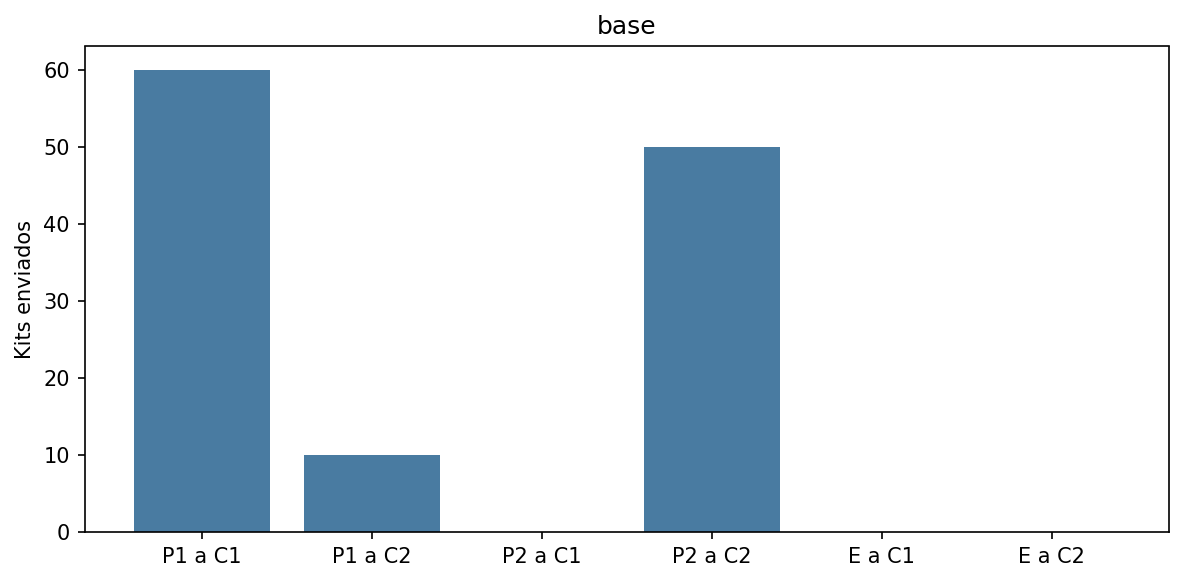

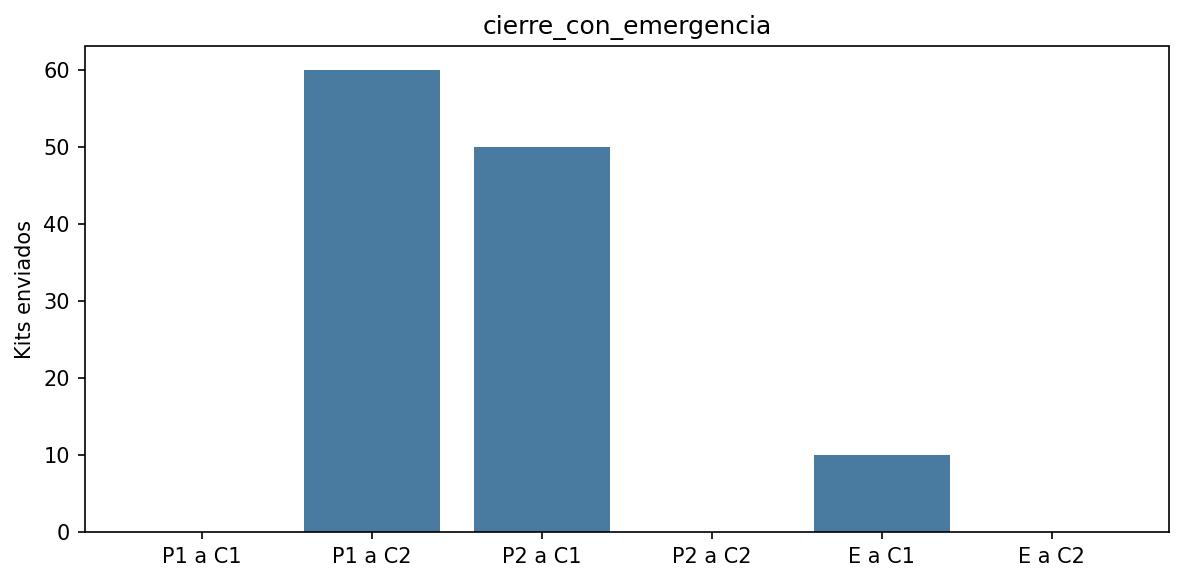

In [1]:
"""Solución docente de Gestión de Operaciones. Profesor: Manuel López."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
datos = base / "datos"
salida = base / "resultados"
salida.mkdir(exist_ok=True)
parametros = json.loads((datos / "parametros.json").read_text(encoding="utf-8"))

def tabla(df, nombre):
    df.to_csv(salida / (nombre + ".csv"), index=False)
    visible = df if len(df) <= 28 else df.head(12)
    print("\n" + nombre + "\n" + visible.to_string(index=False))
    if len(df) > 28:
        print(f"Vista inicial: {len(df)} filas completas en {nombre}.csv")

def figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(salida / (nombre + ".png"), dpi=150, bbox_inches="tight")
    if "__file__" not in globals():
        plt.show()
    plt.close(fig)

def resumen(obj):
    def convertir(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, np.generic):
            return x.item()
        raise TypeError(type(x))
    (salida / "resumen.json").write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=convertir),
        encoding="utf-8")

from scipy.optimize import linprog
prov=pd.read_csv(datos / "proveedores.csv")
centros=pd.read_csv(datos / "centros.csv")
arcos=pd.read_csv(datos / "arcos.csv")
escenarios=pd.read_csv(datos / "escenarios.csv")
assert not arcos[["proveedor","centro"]].duplicated().any()
assert set(arcos.proveedor)<=set(prov.proveedor)
assert set(arcos.centro)<=set(centros.centro)
A=np.array([[float(p==i) for p in arcos.proveedor] for i in prov.proveedor])
B=np.array([[float(c==j) for c in arcos.centro] for j in centros.centro])
tol=parametros["tolerancia"]; resultados={}
for sc in escenarios.itertuples():
    bounds=[]
    for r in arcos.itertuples():
        cerrado=(sc.cerrar_p1_c1 and r.proveedor=="P1" and r.centro=="C1")
        inactivo=(not sc.habilitar_emergencia and r.proveedor=="E")
        bounds.append((0,0 if cerrado or inactivo else None))
    opt=linprog(arcos.costo_unitario,A_ub=A,b_ub=prov.oferta_kits,
                A_eq=B,b_eq=centros.demanda_kits,bounds=bounds,method="highs")
    if not opt.success:
        resultados[sc.escenario]={"status":int(opt.status),"costo":None}
        print(sc.escenario, "SIN PLAN FACTIBLE:", opt.message)
        if sc.escenario!="cierre" or opt.status!=2:
            raise RuntimeError(opt.message)
        continue  # No consultar x de una solución inexistente.
    assert np.max(np.abs(B@opt.x-centros.demanda_kits))<=tol
    assert np.all(A@opt.x<=prov.oferta_kits+tol) and np.all(opt.x>=-tol)
    for k,(_,maximo) in enumerate(bounds):
        if maximo==0:
            assert abs(opt.x[k])<=tol
    flujos=arcos.copy(); flujos["kits"]=opt.x
    flujos["costo_total"]=opt.x*arcos.costo_unitario
    tabla(flujos,"flujos_"+sc.escenario)
    uso=prov.copy(); uso["enviados"]=A@opt.x
    uso["capacidad_no_usada"]=uso.oferta_kits-uso.enviados
    tabla(uso,"uso_"+sc.escenario)
    fig,ax=plt.subplots(figsize=(8,4))
    labels=flujos.proveedor+" a "+flujos.centro
    ax.bar(labels,flujos.kits,color="#497ba1")
    ax.set(ylabel="Kits enviados",title=sc.escenario)
    figura(fig,"flujos_"+sc.escenario)
    resultados[sc.escenario]={"status":0,"costo":opt.fun,"flujos":opt.x}
assert resultados["base"]["costo"]==220
assert resultados["cierre"]["status"]==2
assert resultados["cierre_con_emergencia"]["costo"]==600
resumen(resultados)
